In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Carregar dataset
df = pd.read_excel("../dataset/dataset_velocidade_v2.xlsx")

# Visualizar
print(df.head())


  movimento  tempo  velocidade  flag
0    avanco  1.230    0.081301     1
1    avanco  1.214    0.082372     1
2    avanco  1.213    0.082440     1
3    avanco  1.275    0.078431     1
4    avanco  1.405    0.071174     0


In [3]:
# Codificar movimento (string -> número)
le = LabelEncoder()
df['movimento_num'] = le.fit_transform(df['movimento'])
# Features e target
X = df[['velocidade', 'movimento_num']]
y = df['flag']  # 1 = normal, 0 = anomalia

In [4]:
# Separar treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [5]:
# Treinar Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [6]:
# Avaliação rápida
y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[679   0]
 [  0 159]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       679
           1       1.00      1.00      1.00       159

    accuracy                           1.00       838
   macro avg       1.00      1.00      1.00       838
weighted avg       1.00      1.00      1.00       838



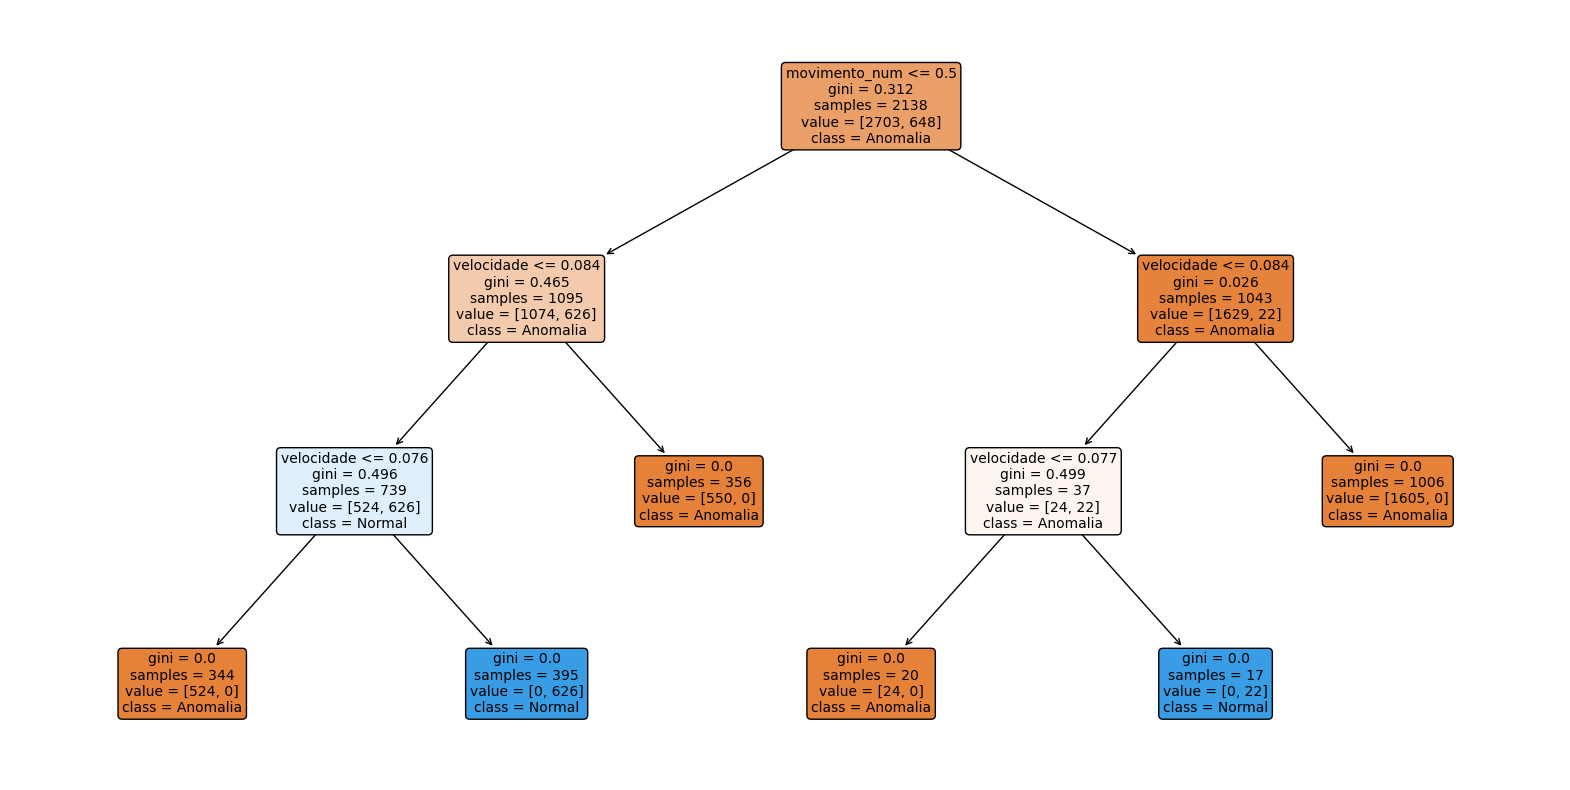

In [7]:
import matplotlib.pyplot as plt
from sklearn import tree

# Selecionar a primeira árvore do Random Forest
estimator = model.estimators_[0]

# Plotar a árvore
plt.figure(figsize=(20,10))
tree.plot_tree(
    estimator, 
    feature_names=['velocidade', 'movimento_num'], 
    class_names=['Anomalia', 'Normal'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()


In [8]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Quantidade de amostras de teste
n_test = 20

# Gerar movimentos aleatórios
movimentos = np.random.choice(['avanco', 'recuo'], size=n_test)

# Gerar velocidades aleatórias:
# 70% normais (0.080 a 0.089), 30% anomalias (0.070 a 0.079)
velocidades = np.concatenate([
    np.random.uniform(0.080, 0.089, int(n_test*0.7)),
    np.random.uniform(0.070, 0.079, int(n_test*0.3))
])
np.random.shuffle(velocidades)

# Criar dataframe
df_test = pd.DataFrame({
    'movimento': movimentos,
    'velocidade': velocidades
})

# Codificar movimento (LabelEncoder)
le = LabelEncoder()
df_test['movimento_num'] = le.fit_transform(df_test['movimento'])

# Prever com modelo já treinado (usando velocidade completa)
y_pred = model.predict(df_test[['velocidade', 'movimento_num']])
df_test['pred_flag'] = y_pred

# Mostrar resultado
print(df_test)


   movimento  velocidade  movimento_num  pred_flag
0     avanco    0.071476              0          0
1      recuo    0.072214              1          0
2     avanco    0.083197              0          1
3      recuo    0.082543              1          1
4     avanco    0.085086              0          0
5      recuo    0.081162              1          1
6     avanco    0.088925              0          0
7     avanco    0.081181              0          1
8     avanco    0.086460              0          0
9      recuo    0.070338              1          0
10    avanco    0.088030              0          0
11    avanco    0.084222              0          0
12    avanco    0.087831              0          0
13     recuo    0.071542              1          0
14    avanco    0.088951              0          0
15     recuo    0.088103              1          0
16     recuo    0.078323              1          1
17     recuo    0.085612              1          0
18     recuo    0.087722       